In [1]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()



True

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-flash-lite-latest")

In [ ]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]
#     operator.add

	

# old_list + new_list

# add_messages

	

# Merge by message ID: append new IDs, replace existing IDs

In [5]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

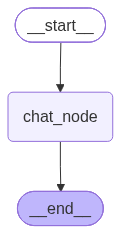

In [7]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()
chatbot

In [14]:
result = chatbot.invoke(initial_state)

last_text = result["messages"][-1].content[0]["text"]
print(last_text)

The capital of India is **New Delhi**.


In [ ]:
while True:
    user_msg = input("Type here man ....")

    print("User:", user_msg)

    if user_msg.strip().lower() in {"exit", "bye"}:
        break

    response = llm.invoke('message':[user_msg])

    print("AI:", response.content[0]["text"])

User: hi
AI: Hi there! How can I help you today?
User: capital of dholokpur
AI: The fictional kingdom of Dholakpur (from the animated series *Chhota Bheem*) does not have a separate capital city named; rather, **Dholakpur itself is the capital kingdom** ruled by Raja Indravarma. 

The stories primarily take place in and around the main royal palace and village of Dholakpur.
User: fine man ur model name plz
AI: I am a large language model created by **Google**.
User: i mean which one 
AI: It looks like context got cut off! Which one what? 

Let me know what you were comparing or talking about in your previous thought, and I'll help you figure it out.
User: so u have no memeory now right
AI: Correct! In this new chat session, I don't have any memory of our past conversations. Every time we start a new chat, it's a completely blank slate for my privacy and security. 

What's on your mind today?
User: exit


In [ ]:

from langchain_core.messages import HumanMessage

state = {"messages": []}

while True:
    user_msg = input("Type here man: ")

    if user_msg.strip().lower() in {"exit", "bye"}:
        break

    # Add user's message have memory past conversation
    state["messages"].append(HumanMessage(content=user_msg))

    # Invoke graph
    state = chatbot.invoke(state)

    # Print latest AI reply
    print("AI:", state["messages"][-1].content[0]["text"])

AI: Hi Satyajit! Nice to meet you. How can I help you today?
AI: Ah, I see your confusion! This is a very common point of confusion when learning LangGraph. 

Even though you are using a reducer (like `add_messages`), **you still need to use `.append()`** in Python because `state["messages"]` is a Python list. 

Here is the breakdown of why this happens step-by-step:

### 1. Python's `.append()` is just adding to the local variable
In Python, `state["messages"]` gets the current list of messages from your state. When you write `.append(HumanMessage(...))`, you are simply telling Python: *"Hey, take this new message and shove it into the end of this specific list object in memory."*

### 2. The Reducer's job happens *after* the Node finishes
This is the magic of LangGraph. Your Node function must **return** a dictionary containing the updates. For example:
```python
return {"messages": [HumanMessage(content=user_msg)]}
# OR if you mutated the list:
return {"messages": state["messages"]}